In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [2]:
def modplot(ax,minorticks=True,removeax=True):
    if(minorticks):
        from matplotlib.ticker import AutoMinorLocator
        minorLocator   = AutoMinorLocator()
        ax.yaxis.set_minor_locator(minorLocator)
        minorLocator   = AutoMinorLocator()
        ax.xaxis.set_minor_locator(minorLocator)

    if(removeax):
        ax.spines['right'].set_visible(False)
        ax.get_yaxis().tick_left()
        ax.spines['top'].set_visible(False)
        ax.get_xaxis().tick_bottom()

class case:
    def __init__(self, nx, ny, nz, ndays, year, kind, label, loc='right'):
        self.nx = nx
        self.ny = ny
        self.nz = nz
        self.ndays = ndays
        self.N  = nx*ny*nz
        self.Nxd = self.N * self.ndays
        self.year = year
        self.kind = kind
        self.label = label
        self.loc = loc

        print(label, self.N)

class moore:
    def __init__(self, n0, y0, p, y1):
        self.p    = p
        self.year = np.arange(y0, y1)
        self.dt   = self.year - self.year[0]
        self.N    = n0 * 2**(self.dt / p)

In [3]:
LES_cases = []
DNS_cases = []

L_HDCP  = 1000000
n_HDCP  = 4690
dx_HDCP = L_HDCP / n_HDCP

n_10 = L_HDCP / 10. 
n_1  = L_HDCP / 1. 

LES_cases.append(case(24,    14,    20,  0.1,  1970, 'LES', 'Deardorff (1970)'))
LES_cases.append(case(40,    40,    40,  0.1,  1980, 'LES', 'Deardorff (1980)'))
LES_cases.append(case(96,    96,    96,  0.1,  1988, 'LES', 'Moeng (1988)'))
LES_cases.append(case(400,   400,   400, 0.5,  2006, 'LES', 'Beare (2006)'))
LES_cases.append(case(1024,  1024,  1024,0.1,  2011, 'LES', 'Sullivan (2011)'))
LES_cases.append(case(4690,  4690,  150, 5,    2015, 'LES', r'HD(CP)$^2$ (2015)'))
LES_cases.append(case(30720, 2048,  128, 3*50, 2026, 'LES', r'RCEMIP-II (2026)', 'left'))

#DNS_cases.append(case(192,  129,  160,  1987, 'DNS', 'Kim (1987)'))
#DNS_cases.append(case(384,  257,  384,  1999, 'DNS', 'Moser (1999)'))
#DNS_cases.append(case(3072, 2304, 385,  2004, 'DNS', 'Del Alamo (2004)'))
##DNS_cases.append(case(8192, 4096, 1024, 2014, 'DNS', 'Bernardini (2014)'))
#DNS_cases.append(case(5120, 5120, 840, 2014, 'DNS', 'Garcia and Mellado (2014)'))
#DNS_cases.append(case(32768, 32768, 32768, 2024, 'DNS', 'Yeung et al. (2024)'))

#m_dns = moore(192*129*160, 1987, 1.8, 2100)
m_les = moore(24*14*20,    1970, 2.5,  2100)

Deardorff (1970) 6720
Deardorff (1980) 64000
Moeng (1988) 884736
Beare (2006) 64000000
Sullivan (2011) 1073741824
HD(CP)$^2$ (2015) 3299415000
RCEMIP-II (2026) 8053063680


## Only grid points.

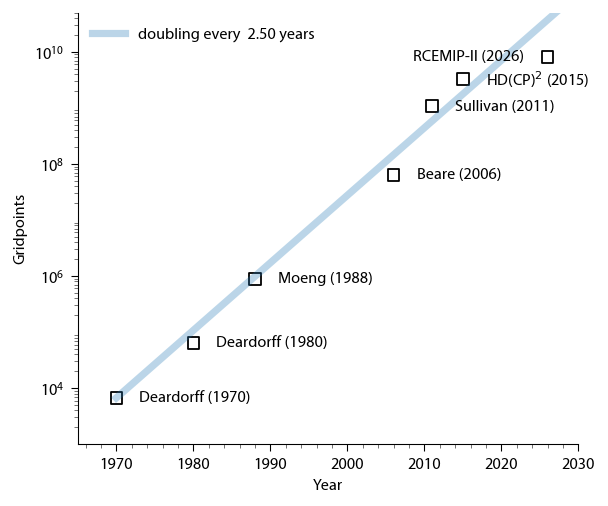

In [4]:
fig = plt.figure(figsize=(5,4)) #
#                   L    B    R    T    ws  hs
fig.subplots_adjust(0.14,0.12,0.91,0.95,0.22,0.21)

ax = plt.subplot(111)
modplot(ax)
for c in LES_cases:
    plt.scatter(c.year, c.N, s=40, color='k', marker='s', facecolor='none')
    if c.loc == 'right':
        plt.text(c.year+3, c.N, c.label, va='center', ha='left')
    else:
        plt.text(c.year-3, c.N, c.label, va='center', ha='right')
#for c in DNS_cases:
#    plt.scatter(c.year, c.N, s=50, color='k', marker='o', facecolor='none')
#    plt.text(c.year-3, c.N, c.label, va='center', ha='right', size=11)

#plt.plot(m_dns.year, m_dns.N, color='tab:blue', linewidth=4, alpha=0.3, label='doubling = {:5.2f} year'.format(m_dns.p))
plt.plot(m_les.year, m_les.N, color='tab:blue', linewidth=4, alpha=0.3, label='doubling every {:5.2f} years'.format(m_les.p))
ax.set_yscale('log')
plt.yticks([10**4, 10**6, 10**8, 10**10, 10**12, 10**14, 10**16])
plt.legend(frameon=False, loc=2)
plt.xlabel('Year')
plt.ylabel('Gridpoints')

plt.xlim(1965,2030)
plt.ylim(1e3, 5e10)

plt.savefig('figures/moore_les.png')
plt.savefig('figures/moore_pdf.png')

## Grid points times integration time

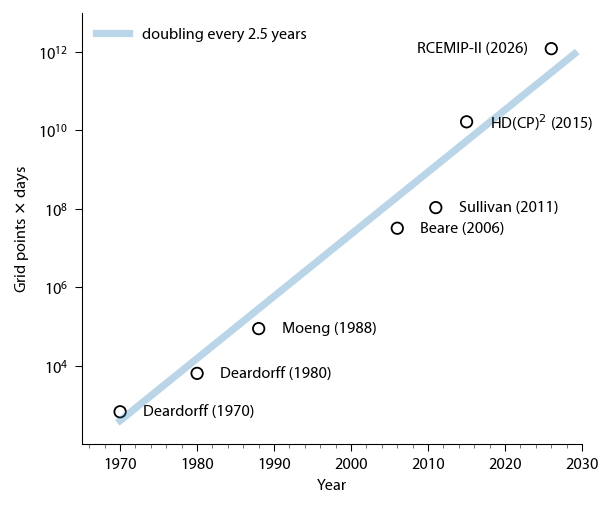

In [5]:
m_les2 = moore(400,  1970, 1.9,  2030)

fig = plt.figure(figsize=(5,4)) #
#                   L    B    R    T    ws  hs
fig.subplots_adjust(0.14,0.12,0.91,0.95,0.22,0.21)

ax = plt.subplot(111)
modplot(ax)
for c in LES_cases:
    plt.scatter(c.year, c.Nxd, s=40, color='k', marker='o', facecolor='none')
    if c.loc == 'right':
        plt.text(c.year+3, c.Nxd, c.label, va='center', ha='left')
    else:
        plt.text(c.year-3, c.Nxd, c.label, va='center', ha='right')

plt.plot(m_les2.year, m_les2.N, color='tab:blue', linewidth=4, alpha=0.3, label='doubling every {:.1f} years'.format(m_les.p))
ax.set_yscale('log')
plt.yticks([10**4, 10**6, 10**8, 10**10, 10**12, 10**14, 10**16])
plt.legend(frameon=False, loc=2)
plt.xlabel('Year')
plt.ylabel(r'Grid points $\times$ days')

plt.xlim(1965,2030)
plt.ylim(1e2, 1e13)

plt.savefig('figures/moore_les_2.png')
plt.savefig('figures/moore_pdf_2.png')